# 4-Lobe Lightbridge Fuel

## Gas Displacer

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import kaist
from ttnte.cad.curves import qtrlobe
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = kaist()

In [3]:
D = 1.26 # Fuel width
D2 = D*0.5
X = 1.36 # Channel pitch
delta = 0.306 # Width of lobes
y2 = delta * 0.5
d = 0.04 # Thickness of cladding at valleys
dmax = 0.102 # Thickness of cladding at ends of the lobes
R = 0.297 # Radius defining outer curve of valleys
a = 0.156 # Displacer width

y1 = y2-d # Half of width of inner lobe
x1 = (D2 - R - y2 - dmax) # Portrusion of innerlobe
x2 = x1 + dmax # Portrusion of outer lobe

In [4]:
# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
burn = cad.line(p1=(a / (2 ** 0.5), 0), p0=(0, a / (2 ** 0.5)))
fuel = qtrlobe(outrad=R + d, portrs=x1, hfwidth=y1 )
clad = qtrlobe(outrad=R, portrs=x2, hfwidth=y2 )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [5]:
# NURBS patches
patches = {}
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    osec = origin.slice(0, sections[i], sections[i + 1])
    bsec = burn.slice(0, sections[i], sections[i + 1])
    fsec = fuel.slice(0, sections[i], sections[i + 1])
    csec = clad.slice(0, sections[i], sections[i + 1])

    # Create patches
    patches[cad.ruled(osec, bsec)] = "Gas"
    patches[cad.ruled(bsec, fsec)] = "UO2 3%"
    patches[cad.ruled(fsec, csec)] = "Guide Tube"
    patches[cad.ruled(csec, edges[i])] = "Water"

In [6]:
# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 6, 2)
    
# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

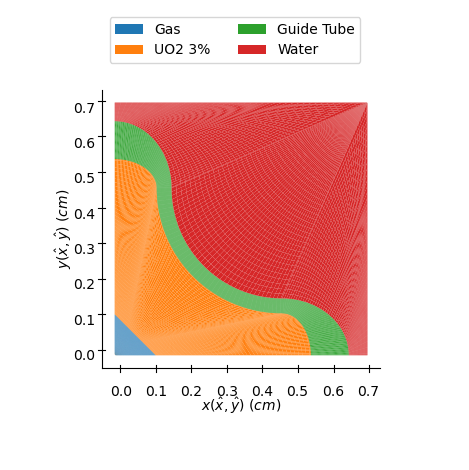

In [7]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False)
plt.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.savefig("./figs/four_lobe_gas.png", dpi=300)
plt.show()

In [8]:
print("Assemble system in COOrdinate format")
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
H_m, S_m, F_m, B_in_m, B_out_m = assembler.build()

# Create operators in TT format
print("\nAssemble system in TT format")
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H_tt, S_tt, F_tt, B_in_tt, B_out_tt = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info_gas.csv")

Assemble system in COOrdinate format
Discretization: N = 64, G = 7, P = 12, A = 5, B = 5
Assembling Patch 1
Step            Shape                     Compression  Elapsed Time (s)
H               134400,134400               37229.92        0.24
S               2,2100,2100                      inf        0.24
F               2100,2100                        inf        0.24
B_in            134400,134400              471578.95        0.33
B_out           134400,134400              479197.77        0.40
Assembling Patch 2
Step            Shape                     Compression  Elapsed Time (s)
H               134400,134400               37229.92        0.63
S               2,2100,2100                   169.67        0.64
F               2100,2100                     193.91        0.64
B_in            134400,134400              335214.34        0.73
B_out           134400,134400              346001.61        0.79
Assembling Patch 3
Step            Shape                     Compression  Elaps

In [9]:
k, psi = eig(
    LHS=LinearOperator([H_tt, B_out_m - B_in_m, -S_tt], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F_tt], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=1,
    linear_solver_opts={
        "max_iterations": 150,
        "threshold": 1e-10,
        "resets": 50,
    },
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 1.25129368, Angular Flux L2-Error = 3.56862424, Elapsed Time = 35.831
-- (1): k = 1.25704411, Angular Flux L2-Error = 0.00259853, Elapsed Time = 71.796
-- (2): k = 1.25705512, Angular Flux L2-Error = 1.289e-05, Elapsed Time = 108.922
-- (3): k = 1.25705521, Angular Flux L2-Error = 2.1e-07, Elapsed Time = 144.445
-- (4): k = 1.25705521, Angular Flux L2-Error = 1e-08, Elapsed Time = 173.965
-- Converged: k = 1.25705521, Elapsed Time = 173.965


In [10]:
# Get OpenMC solution
k_mc = [1.25669, 0.00007]
phi_mc = np.load("./openmc/openmc_gas/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: 41763.52117190418 +/- 6e-05 pcm


<Figure size 640x480 with 0 Axes>

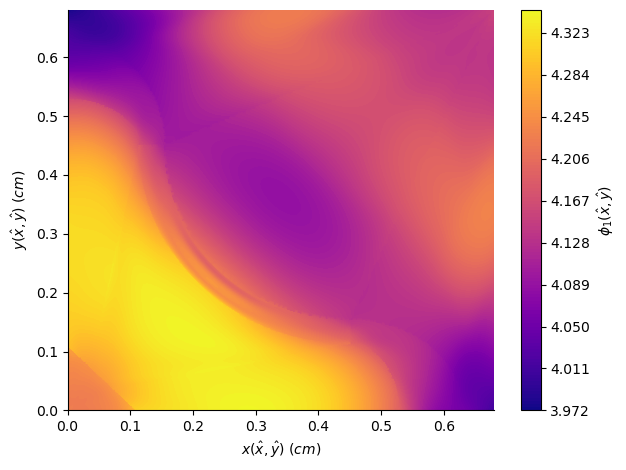

<Figure size 640x480 with 0 Axes>

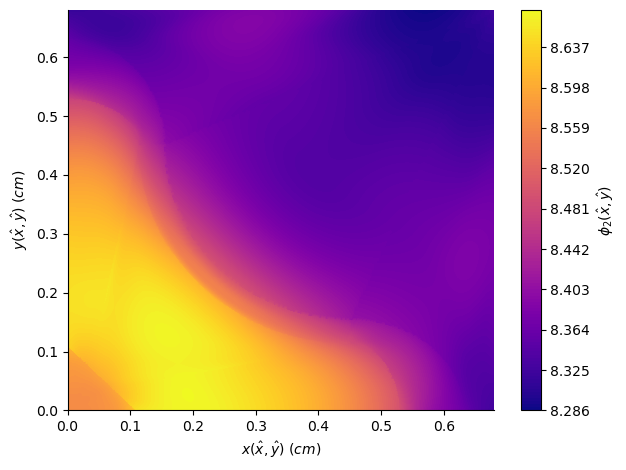

<Figure size 640x480 with 0 Axes>

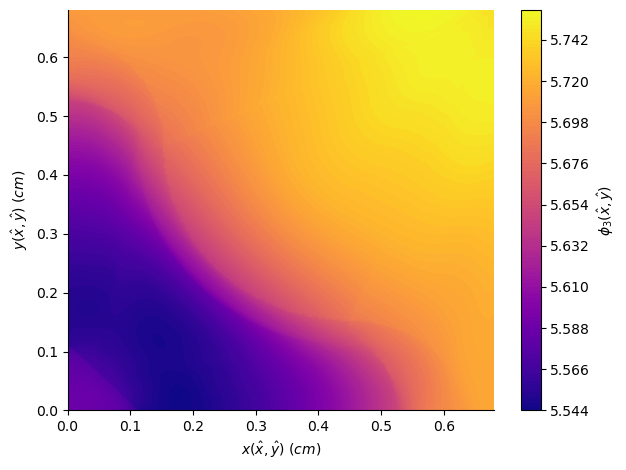

<Figure size 640x480 with 0 Axes>

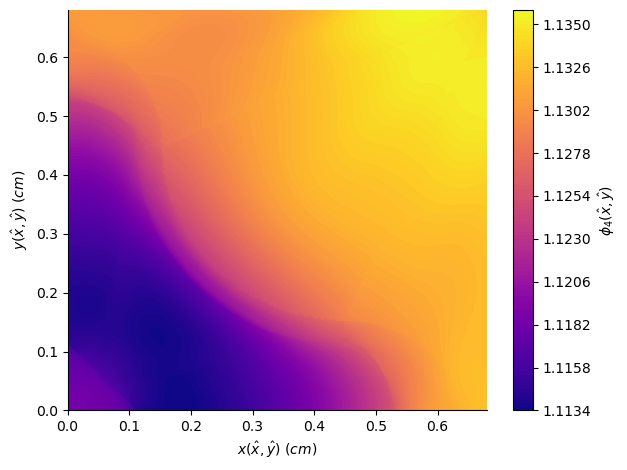

<Figure size 640x480 with 0 Axes>

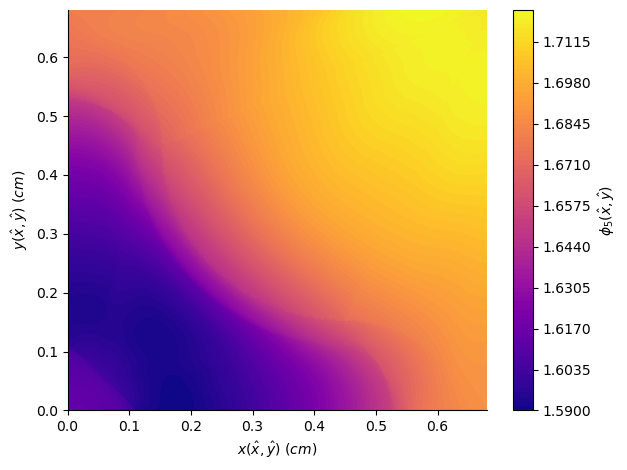

<Figure size 640x480 with 0 Axes>

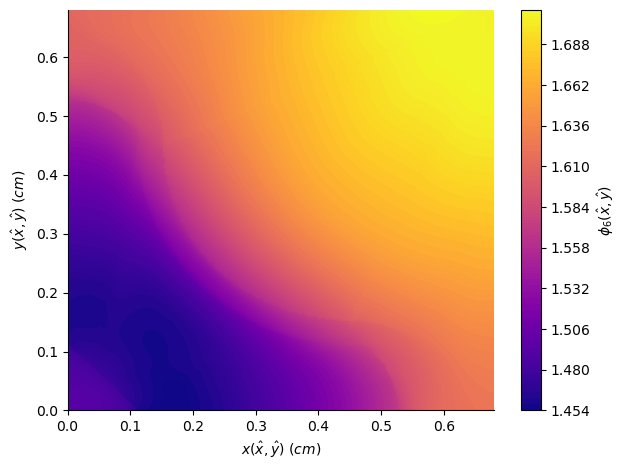

<Figure size 640x480 with 0 Axes>

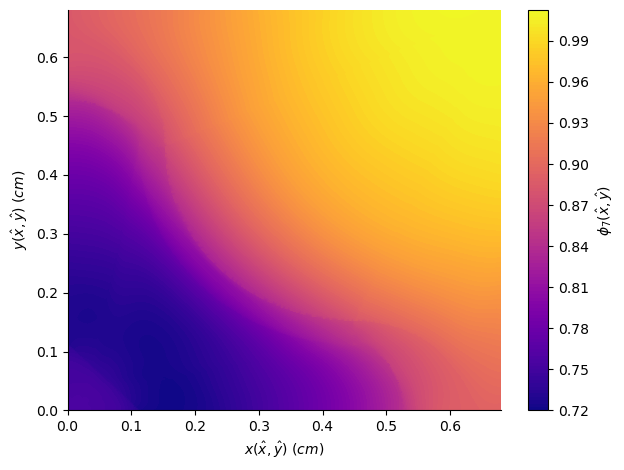

In [11]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(num_nodes=128, plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_gas{g + 1}.png", dpi=300)
    plt.show()

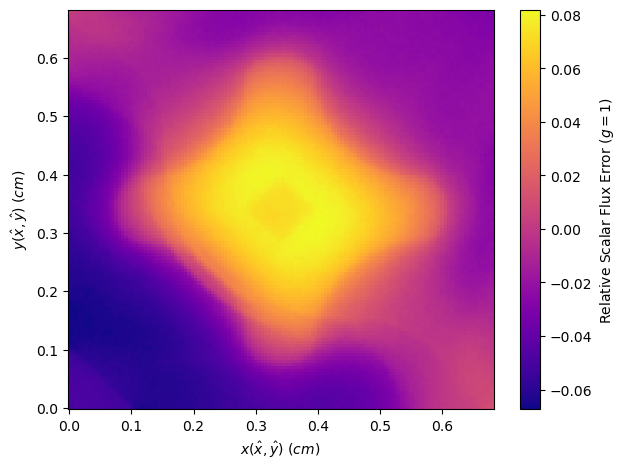

Scalar flux Relative L2-error (g = 1): 0.041289920183299904


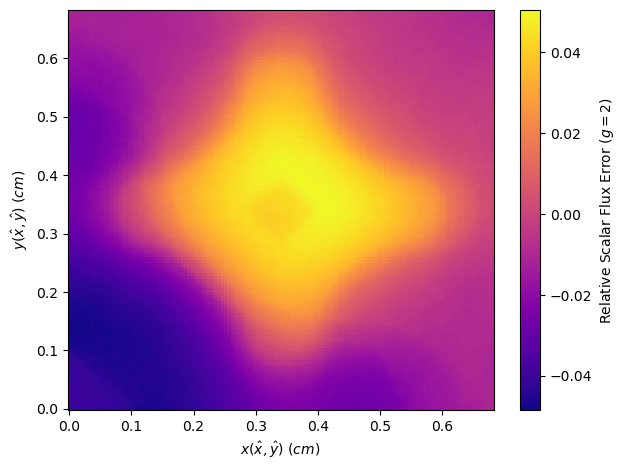

Scalar flux Relative L2-error (g = 2): 0.02631096303529901


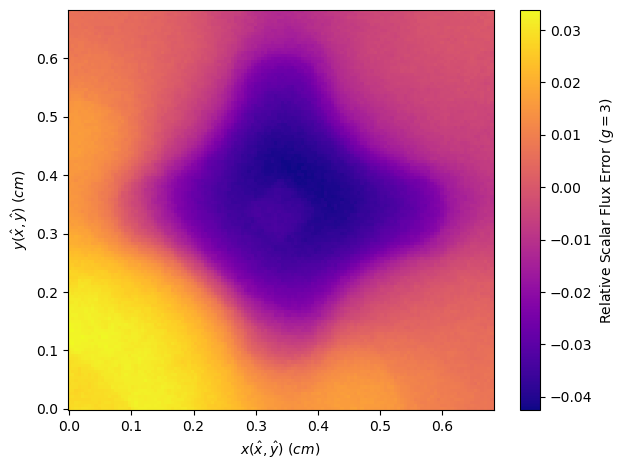

Scalar flux Relative L2-error (g = 3): 0.020008502266790885


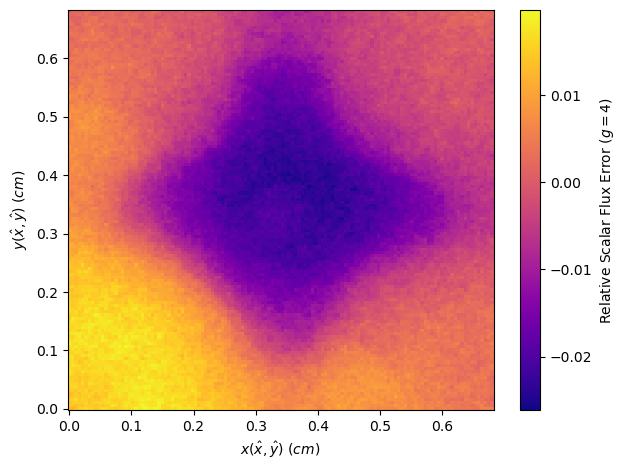

Scalar flux Relative L2-error (g = 4): 0.011405384581147952


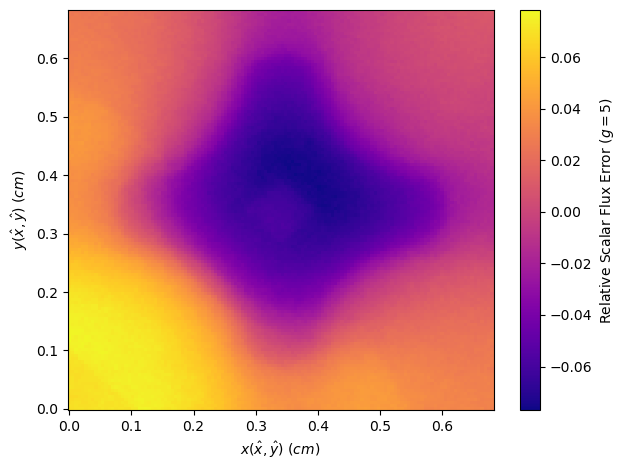

Scalar flux Relative L2-error (g = 5): 0.03972768917979059


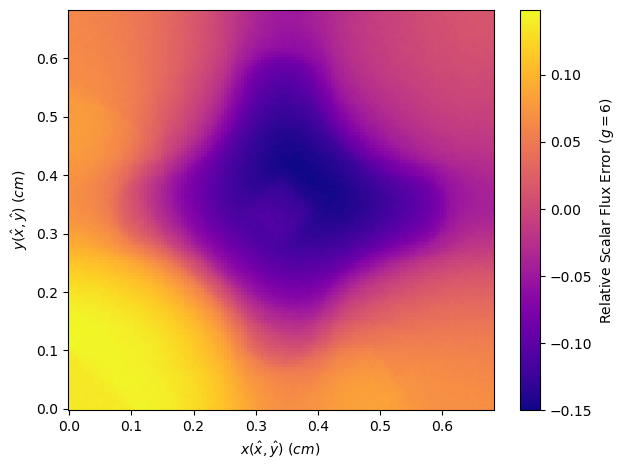

Scalar flux Relative L2-error (g = 6): 0.07738201292566665


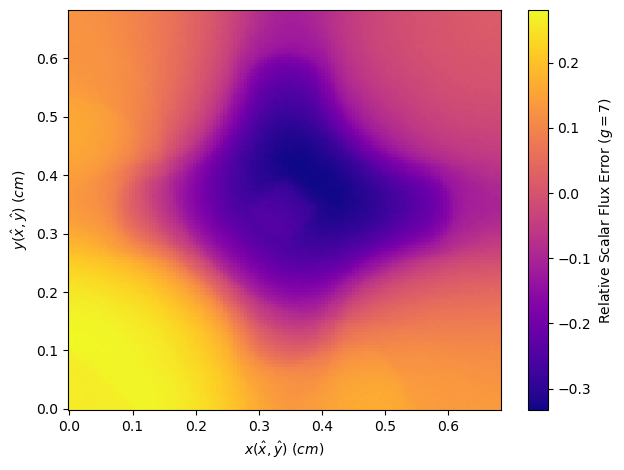

Scalar flux Relative L2-error (g = 7): 0.15688554012503592
Total scalar flux Relative L2-error: 0.032060942163196014


In [12]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, X / 2, phi_mc.shape[1]),
    np.linspace(0, X / 2, phi_mc.shape[2]),
)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    cmesh = plt.pcolormesh(
        X, Y, (phi_mc[g,] - phi_avg[g,]) / phi_mc[g,], cmap="plasma"
    )
    plt.colorbar(
        cmesh, 
        label=f"Relative Scalar Flux Error ($g = {g + 1}$)",
    )
    plt.xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    plt.ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_gas{g + 1}_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)